# Spectral diagnostics: non-normal shear and Nyquist toys

This notebook reads `SpectralDiagnostics` from discrete
`compute_spectrum` on four maps: the identity, a $2\times 2$
non-normal shear with a closed-form $\kappa_i$, a
Nyquist-adjacent $\lambda=-1$ diagonal, and a $\rho<1$
shear whose $\|K^{k}\|$ exceeds $\rho^{k}$. It shows when
to inspect $\kappa(V)$, Wilkinson $\kappa_i$, and Nyquist
flags, and when those fields are not a bound.

**Honesty.** These fields are not a finite-horizon bound on
$\|K^{k}\|$ and not a sampling-theorem identification
result. `CONDITION_WARN` is $10^{6}$. Frequencies are
principal values in cycles per unit time; phase unwrapping
does not recover aliases. This notebook does **not**
download METR-LA.


## Setup

Package version, Float64 toys, and warning capture.


In [1]:
from __future__ import annotations

import math
import os
import warnings

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph.spectrum_types import (
    CONDITION_WARN,
    DefectiveSpectrumError,
    KoopmanSpectrum,
    compute_spectrum,
)

print("koopman_graph", koopman_graph.__version__)
print("CONDITION_WARN", CONDITION_WARN)


koopman_graph 0.15.0
CONDITION_WARN 1000000.0


## Motivation and background

A list of $|\lambda|$ or a unit-disk sketch is the naive
check. It misses two failure modes this helper flags.

First, a non-normal map can produce finite-horizon
transients with $\|K^{k}\|$ above $\rho(K)^{k}$ even when
every $|\lambda|\le 1$ (Trefethen and Embree 2005, *Spectra
and Pseudospectra*,
[doi:10.1515/9780691213101](https://doi.org/10.1515/9780691213101)).
`SpectralDiagnostics` reports the 2-norm condition
$\kappa(V)$ of **column-normalized** right eigenvectors,
per-mode Wilkinson sensitivities
$\kappa_i=1/|w_i^{H} v_i|$ (Wilkinson 1965, *The Algebraic
Eigenvalue Problem*), and Frobenius departure
$\|KK^{H}-K^{H}K\|_{F}$. None of those quantities is a
bound on $\|K^{k}\|$.

Second, a real eigenvalue near $-1$ sits at discrete
Nyquist phase. The Nyquist frequency is $1/(2\Delta t)$ in
cycles per unit time. Reported frequencies remain principal
values. Zeng, Yue, Mauroy, Gonçalves, and Yuan (2022) is
related sampling-theorem literature for continuous-time
identification
([doi:10.1109/CDC51059.2022.9992482](https://doi.org/10.1109/CDC51059.2022.9992482));
this helper does not implement that theorem.

The identity is the normal control
($\kappa(V)\approx 1$, departure $0$). The triangular
shear $[[1,a],[0,2]]$ has a closed-form $\kappa_i$ and
$\rho=2$, so radius alone already grows. A separate
$\rho<1$ shear isolates transients later.


## Minimal example

Identity versus the $a=10$ shear $[[1,10],[0,2]]$. Both
$\kappa_i$ equal $\sqrt{1+a^{2}}$. The printed $\kappa(V)$
is compared with `CONDITION_WARN`: this shear is
non-normal and well below the amplitude warning. Its
$\rho=2$ is a spectral-radius fact, not the non-normality
demo.


In [2]:
identity = compute_spectrum(torch.eye(2, dtype=torch.float64), time_step=1.0)
assert identity.diagnostics is not None
print("identity kappa(V)", identity.diagnostics.eigenvector_condition)
print("identity departure", identity.diagnostics.departure_from_normality)
print("identity Nyquist", identity.diagnostics.nyquist_frequency)

shear = 10.0
nonnormal = compute_spectrum(
    torch.tensor([[1.0, shear], [0.0, 2.0]], dtype=torch.float64),
    time_step=1.0,
)
diag = nonnormal.diagnostics
assert diag is not None
expected_kappa_i = math.sqrt(1.0 + shear**2)
print("shear kappa_i", diag.eigenvalue_sensitivities.tolist(), "oracle", expected_kappa_i)
print(
    "shear kappa(V)",
    diag.eigenvector_condition,
    "CONDITION_WARN",
    CONDITION_WARN,
)
print("shear departure", diag.departure_from_normality)
print("shear rho", float(nonnormal.magnitudes.max()))
assert diag.eigenvector_condition > 1.0
assert diag.eigenvector_condition < CONDITION_WARN
assert diag.departure_from_normality > 0.0


identity kappa(V) 1.0
identity departure 0.0
identity Nyquist 0.5
shear kappa_i [10.049875621120888, 10.04987562112089] oracle 10.04987562112089
shear kappa(V) 20.049875621120886 CONDITION_WARN 1000000.0
shear departure 142.12670403551894
shear rho 2.0


## Progressive deep dive

Diagonal $\mathrm{diag}(-1, 0.5)$ at $\Delta t=0.25$.
Nyquist frequency is $1/(2\Delta t)=2$ cycles per unit
time. $\lambda=-1$ has argument $\pi$ and sets one
aliasing flag; the second mode does not.


In [3]:
time_step = 0.25
caught: list[warnings.WarningMessage] = []
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always", UserWarning)
    nyquist = compute_spectrum(
        torch.diag(torch.tensor([-1.0, 0.5], dtype=torch.float64)),
        time_step=time_step,
    )
nyquist_warnings = [w for w in caught if "Nyquist" in str(w.message)]
assert nyquist_warnings, "expected a Nyquist UserWarning"
assert nyquist.diagnostics is not None
print("Nyquist warning fired:", str(nyquist_warnings[0].message)[:80], "...")
print(
    "nyquist_frequency",
    nyquist.diagnostics.nyquist_frequency,
    "oracle",
    1.0 / (2.0 * time_step),
)
print("aliasing_warning", nyquist.diagnostics.aliasing_warning.tolist())


Nyquist warning fired: One or more discrete-time eigenvalues have argument within 0.001 rad of pi (Nyqu ...
nyquist_frequency 2.0 oracle 2.0
aliasing_warning [True, False]


Nearly parallel eigenvector columns exceed
`CONDITION_WARN` on `mode_amplitudes`. The solve may still
proceed. This cell builds a manual `KoopmanSpectrum` with
`diagnostics=None`; the method then recomputes $\kappa(V)$
from $V$.


In [4]:
scale = 1e-8
vectors = torch.tensor(
    [[1.0 + 0.0j, 1.0 + 0.0j], [0.0 + 0.0j, scale]],
    dtype=torch.complex128,
)
ill = KoopmanSpectrum(
    eigenvalues=torch.ones(2, dtype=torch.complex128),
    eigenvectors=vectors,
    magnitudes=torch.ones(2, dtype=torch.float64),
    growth_rates=torch.zeros(2, dtype=torch.float64),
    frequencies=torch.zeros(2, dtype=torch.float64),
    time_step=1.0,
)
assert ill.diagnostics is None
amp_caught: list[warnings.WarningMessage] = []
with warnings.catch_warnings(record=True) as amp_caught:
    warnings.simplefilter("always", UserWarning)
    _ = ill.mode_amplitudes(torch.tensor([1.0, 0.5], dtype=torch.float64))
cond_warnings = [w for w in amp_caught if "CONDITION_WARN" in str(w.message)]
assert cond_warnings, "expected a CONDITION_WARN UserWarning"
print("CONDITION_WARN warning fired")
print("manual spectrum diagnostics", ill.diagnostics)


CONDITION_WARN warning fired
manual spectrum diagnostics None


A zero column in $V$ is singular.
`mode_amplitudes` raises `DefectiveSpectrumError` (a
`LinAlgError`) with a Schur-subspace hint; it does not
compute a Schur form.

In [5]:
singular = KoopmanSpectrum(
    eigenvalues=torch.ones(2, dtype=torch.complex128),
    eigenvectors=torch.tensor(
        [[1.0 + 0.0j, 0.0 + 0.0j], [0.0 + 0.0j, 0.0 + 0.0j]],
    ),
    magnitudes=torch.ones(2, dtype=torch.float64),
    growth_rates=torch.zeros(2, dtype=torch.float64),
    frequencies=torch.zeros(2, dtype=torch.float64),
    time_step=1.0,
)
raised: DefectiveSpectrumError | None = None
try:
    singular.mode_amplitudes(torch.ones(2, dtype=torch.float64))
except DefectiveSpectrumError as exc:
    raised = exc
assert raised is not None
print("DefectiveSpectrumError fired:", str(raised)[:80], "...")

DefectiveSpectrumError fired: Eigenvector matrix is singular (defective or numerically non-diagonalizable). Do ...


## Results

Unit-disk sketch of the identity and the $\rho=2$ shear.
The identity is an open blue marker drawn on top of the
shear so the coincidence at $\lambda=1$ stays visible.
Filled orange marks the shear at $\lambda=1$ (on the
circle) and $\lambda=2$ (outside). The point at
$\mathrm{Re}\,\lambda=2$ is spectral radius, not
non-normality: the circle does not encode $\kappa(V)$ or
departure.


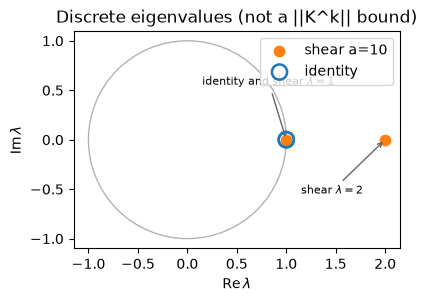

In [6]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
circ = plt.Circle((0.0, 0.0), 1.0, fill=False, color="0.7")
ax.add_patch(circ)
ax.scatter(
    nonnormal.eigenvalues.real,
    nonnormal.eigenvalues.imag,
    s=55,
    color="C1",
    zorder=3,
    label="shear a=10",
)
ax.scatter(
    identity.eigenvalues.real,
    identity.eigenvalues.imag,
    s=120,
    facecolors="none",
    edgecolors="C0",
    linewidths=1.8,
    zorder=4,
    label="identity",
)
ax.annotate(
    r"identity and shear $\lambda=1$",
    xy=(1.0, 0.0),
    xytext=(0.15, 0.55),
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": "0.4"},
)
ax.annotate(
    r"shear $\lambda=2$",
    xy=(2.0, 0.0),
    xytext=(1.15, -0.55),
    fontsize=8,
    arrowprops={"arrowstyle": "->", "color": "0.4"},
)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$\mathrm{Re}\,\lambda$")
ax.set_ylabel(r"$\mathrm{Im}\,\lambda$")
ax.set_title("Discrete eigenvalues (not a ||K^k|| bound)")
ax.legend()
fig.tight_layout()
plt.show()


The next map is $[[0.9, 10],[0, 0.5]]$ with $\rho=0.9<1$.
Both eigenvalues lie inside the unit disk. The plot is
$\|K^{k}\|_{2}$ versus $\rho^{k}$. Look for the printed
peak of $\|K^{k}\|_{2}$ near $k=3$, while $\rho^{k}$ is
already below $1$. That gap is the transient the spectrum
does not certify. `SpectralDiagnostics` on this map has
$\kappa(V)>1$ and positive departure; it does not compute
$\|K^{k}\|$.


inside-disk evals [0.9, 0.5]
inside-disk kappa(V) 50.01999200639361
inside-disk departure 141.53444810363305
peak k 3 ||K^k|| 15.118102713923355 rho^k 0.7290000000000001


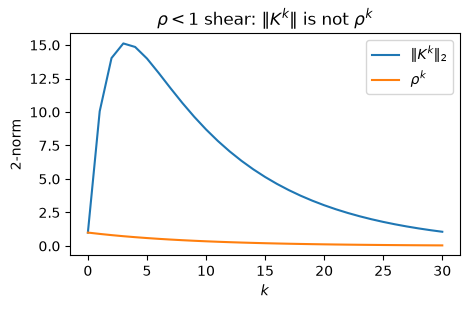

In [7]:
rho = 0.9
inside = torch.tensor([[rho, 10.0], [0.0, 0.5]], dtype=torch.float64)
inside_spec = compute_spectrum(inside, time_step=1.0)
inside_diag = inside_spec.diagnostics
assert inside_diag is not None
print("inside-disk evals", inside_spec.eigenvalues.real.tolist())
print("inside-disk kappa(V)", inside_diag.eigenvector_condition)
print("inside-disk departure", inside_diag.departure_from_normality)
assert float(inside_spec.magnitudes.max()) < 1.0
assert inside_diag.eigenvector_condition > 1.0
assert inside_diag.departure_from_normality > 0.0

horizon = 31
steps = list(range(horizon))
norm_hist = []
envelope = []
for k in steps:
    powered = torch.linalg.matrix_power(inside, k)
    norm_hist.append(float(torch.linalg.matrix_norm(powered, ord=2)))
    envelope.append(rho**k)
peak_k = max(steps, key=lambda k: norm_hist[k])
print("peak k", peak_k, "||K^k||", norm_hist[peak_k], "rho^k", envelope[peak_k])
assert peak_k > 0
assert norm_hist[peak_k] > envelope[peak_k]

fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.plot(steps, norm_hist, label=r"$\|K^{k}\|_{2}$")
ax.plot(steps, envelope, label=r"$\rho^{k}$")
ax.set_xlabel(r"$k$")
ax.set_ylabel("2-norm")
ax.set_title(r"$\rho<1$ shear: $\|K^{k}\|$ is not $\rho^{k}$")
ax.legend()
fig.tight_layout()
plt.show()


## Interpretation / discussion

The identity matches the normal control: $\kappa(V)=1$
and departure $0$. The $a=10$ shear is non-normal
(printed $\kappa(V)\approx 20$, $\kappa_i=\sqrt{101}$) but
well below `CONDITION_WARN`. Its $\rho=2$ already implies
growth, which is why the unit-disk figure is not a
transient-growth demo. The $\rho=0.9$ shear keeps every
$|\lambda|<1$ and still has $\|K^{k}\|_{2}>\rho^{k}$ for
$k\ge 1$. That is the Trefethen–Embree point these fields
flag, not a finite-horizon certificate.

Nyquist warnings are sampling flags, not the Zeng
identification theorem. `CONDITION_WARN` on
`mode_amplitudes` still solves $Va=z^{\top}$. A zero
column in $V$ raises `DefectiveSpectrumError` instead.

`compute_spectrum` and `compute_generator_spectrum`
populate `diagnostics`. Manual `KoopmanSpectrum` objects
may omit them (as in the ill-conditioned amplitude cell).
Eligible Kronecker graph spectra may omit them. Generator
spectra set `nyquist_frequency` to `None`. Resolvent-norm
grids remain a separate opt-in
([40_resdmd_pseudospectra.ipynb](40_resdmd_pseudospectra.ipynb)).


## Takeaways

- **When to use.** After discrete `compute_spectrum`,
  inspect `diagnostics` when the eigenbasis may be
  ill-conditioned, when a real eigenvalue is near $-1$,
  or when a spectrum inside the unit disk may still be
  non-normal.
- **When not to use.** Not a $\|K^{k}\|$ bound, not a
  sampling-theorem identification result, and not a
  resolvent / pseudospectrum certificate. Generator
  spectra have no Nyquist frequency. Manual
  `KoopmanSpectrum` objects and some Kronecker paths may
  omit `diagnostics`.
- Nyquist is $1/(2\Delta t)$ in cycles per unit time;
  frequencies are principal values.
- `CONDITION_WARN=1e6` warns on `mode_amplitudes`; the
  solve may proceed. Singular $V$ raises
  `DefectiveSpectrumError`.
- $\rho>1$ and non-normal transients are different
  facts. A point outside the unit disk is spectral
  radius, not $\kappa(V)$.


## Further reading

- Sphinx: [spectral_diagnostics](../docs/source/spectral_diagnostics.rst),
  [limitations](../docs/source/limitations.rst)
- Wilkinson, J. H. (1965). *The Algebraic Eigenvalue
  Problem*. Clarendon Press (`Wilkinson1965`)
- Trefethen, L. N. and Embree, M. (2005). *Spectra and
  Pseudospectra*. Princeton University Press
  ([doi:10.1515/9780691213101](https://doi.org/10.1515/9780691213101);
  `TrefethenEmbree2005`)
- Zeng, Z., Yue, Z., Mauroy, A., Gonçalves, J., and
  Yuan, Y. (2022). A sampling theorem for exact
  identification of continuous-time nonlinear dynamical
  systems. *CDC*, 6686–6692
  ([doi:10.1109/CDC51059.2022.9992482](https://doi.org/10.1109/CDC51059.2022.9992482);
  `Zeng2022Sampling`). Related literature; this notebook
  does not implement that theorem.
- Example [07_koopman_spectrum.ipynb](07_koopman_spectrum.ipynb)
- Example [40_resdmd_pseudospectra.ipynb](40_resdmd_pseudospectra.ipynb)
  (resolvent-norm grid; not these Euclidean fields)
- Example [54_criticality_monitor.ipynb](54_criticality_monitor.ipynb)
